# Pneumonia Detection using MobileNetV2

In [ ]:
import numpy as np

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Model
from keras.layers import Flatten, Dense
from keras.applications import MobileNetV2

from sklearn.metrics import classification_report, confusion_matrix

## 1. Setup and Imports

First, we import the necessary libraries.

This notebook demonstrates how to build and train a convolutional neural network (CNN) for pneumonia detection from chest X-ray images. We will use a pre-trained MobileNetV2 model as a base and fine-tune it for our specific task.

In [ ]:
base_path = "/content/drive/MyDrive/Pneumonia/chest_xray"

## 2. Data Loading and Exploration

We define the base path to our dataset and then explore the directory structure to understand the data organization. The dataset is expected to have 'train', 'test', and 'val' subdirectories, each containing 'NORMAL' and 'PNEUMONIA' classes.

In [ ]:
import os
print(os.listdir(base_path))
print(os.listdir(base_path + "/train"))

['test', 'train', 'val']
['NORMAL', 'PNEUMONIA']


## 3. Data Preprocessing and Augmentation

We use `ImageDataGenerator` to preprocess the images and perform data augmentation on the training set. This helps in increasing the diversity of the training data and preventing overfitting. The images are rescaled, and various transformations are applied (rotation, zoom, shifts). For validation and test sets, only rescaling is applied.

The `flow_from_directory` method loads images directly from the specified directories, automatically inferring class labels from folder names.

In [ ]:
train_data = ImageDataGenerator(
    rescale = 1/255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    fill_mode='nearest'
).flow_from_directory(
    base_path + "/train",
    target_size = (224,224),
    batch_size = 64,
    class_mode = "binary"
)

test_data = ImageDataGenerator(
    rescale = 1/255
).flow_from_directory(
    base_path + "/test",
    target_size = (224,224),
    batch_size = 64,
    class_mode = "binary",
    shuffle = False
)

val_data  = ImageDataGenerator(
    rescale = 1/255
).flow_from_directory(
    base_path + "/val",
    target_size = (224,224),
    batch_size = 64,
    class_mode = "binary",
    shuffle = False
)

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


## 4. Model Definition

We will use a pre-trained MobileNetV2 model as a base for our classifier. MobileNetV2 is a lightweight deep convolutional neural network that is efficient for mobile and embedded vision applications. We load the model without its top (classification) layers and freeze its weights to use it as a feature extractor. Then, we add our custom classification layers on top.

In [ ]:
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### Freezing Base Model Layers

By setting `layer.trainable = False` for all layers in the `base_model`, we ensure that their weights are not updated during the training of our new top layers. This preserves the learned features from the ImageNet dataset.

In [ ]:
for layer in base_model.layers:
  layer.trainable = False

### Adding Custom Classification Layers

After flattening the output of the base model, we add a `Dropout` layer to prevent overfitting and a `Dense` layer with a sigmoid activation function for binary classification (Pneumonia or Normal).

In [ ]:
from keras.layers import Dropout

x = Flatten()(base_model.output)
x = Dropout(0.5)(x) # Add a Dropout layer with 50% dropout rate
prediction = Dense(1, activation="sigmoid")(x)

### Creating the Final Model

We construct the full model by defining its input (from `base_model.input`) and output (our `prediction` layer).

In [ ]:
model = Model(inputs=base_model.input, outputs=prediction)

### Model Summary

`model.summary()` prints a concise summary of the network architecture, including the number of layers, output shapes, and the number of trainable and non-trainable parameters.

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,320,705 (8.85 MB)

 Trainable params: 62,721 (245.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Compiling the Model

Before training, the model needs to be compiled. We specify the optimizer (`adam`), the loss function (`binary_crossentropy` for binary classification), and the metrics to monitor (`accuracy`).

In [ ]:
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

## 5. Model Training

We train the model using the `fit` method. An `EarlyStopping` callback is used to prevent overfitting by monitoring the validation loss and stopping training if it doesn't improve for a specified number of epochs (`patience=3`). It also restores the best weights found during training.

In [ ]:
from keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss', # Monitor the validation loss
    patience=3,         # Stop if validation loss doesn't improve for 3 epochs
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stopping]
)

Epoch 1/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 522s 6s/step - accuracy: 0.8942 - loss: 0.6188 - val_accuracy: 0.9375 - val_loss: 0.0903
Epoch 2/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.9502 - loss: 0.1987 - val_accuracy: 0.8125 - val_loss: 0.2914
Epoch 3/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.9496 - loss: 0.2307 - val_accuracy: 0.8750 - val_loss: 0.3325
Epoch 4/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.9413 - loss: 0.3040 - val_accuracy: 0.9375 - val_loss: 0.1108


## 6. Visualize Training History

After training, we plot the training and validation accuracy and loss over epochs to observe the model's learning progress and identify potential overfitting.

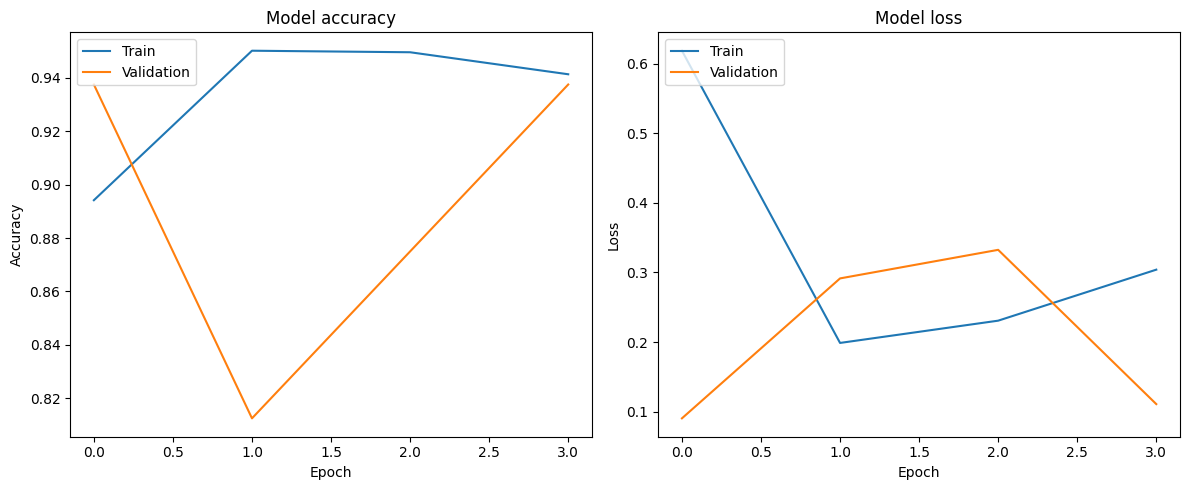

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()

## 7. Model Evaluation

We evaluate the trained model on the unseen test dataset using `model.evaluate()`. This provides the final loss and accuracy metrics.

In [ ]:
model.evaluate(test_data)

10/10 ━━━━━━━━━━━━━━━━━━━━ 164s 17s/step - accuracy: 0.9038 - loss: 0.3272


[0.32721254229545593, 0.9038461446762085]

## 8. Predictions and Classification Report

To get a more detailed understanding of the model's performance, we generate predictions on the test data and compare them against the true labels. We then compute and print the `Confusion Matrix` and `Classification Report`.

- The **Confusion Matrix** shows the counts of true positive, true negative, false positive, and false negative predictions.
- The **Classification Report** provides precision, recall, and f1-score for each class, along with overall accuracy.

In [ ]:
# Get predictions on the test data
predictions = model.predict(test_data)
# Convert probabilities to binary classes (0 or 1)
predicted_classes = np.round(predictions).flatten()

# Get true labels from the test data generator
true_classes = test_data.classes

# Get class labels from the test data generator
class_labels = list(test_data.class_indices.keys())

print('Confusion Matrix')
print(confusion_matrix(true_classes, predicted_classes))

print('\nClassification Report')
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step
Confusion Matrix
[[206  28]
 [ 32 358]]

Classification Report
              precision    recall  f1-score   support

      NORMAL       0.87      0.88      0.87       234
   PNEUMONIA       0.93      0.92      0.92       390

    accuracy                           0.90       624
   macro avg       0.90      0.90      0.90       624
weighted avg       0.90      0.90      0.90       624



## 9. Save the Model

Finally, we save the trained model in the Keras format (`.keras`) so it can be loaded and used later for inference without retraining.

In [ ]:
model.save("mobilenetv2.keras")
print("MobileNetV2 model saved successfully.")

MobileNetV2 model saved successfully.
